# Financial News Topics

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from topic_modeling_utils import *

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
docs = financial_documents()
model, vectorizer, doc_topics, X = fit_lda(docs.text, n_topics=5)
terms = top_terms(model, vectorizer, n_terms=6)
terms.to_csv(OUTPUT / 'financial_news_topic_terms.csv', index=False)
terms.head(20)

,topic,rank,term,weight
0,0,1,improved,1.2003
1,0,2,risk,1.2002
2,0,3,downgrade,1.2000
3,0,4,focused,1.2000
4,0,5,liquidity,1.2000
5,0,6,leverage,1.2000
6,1,1,growth,1.2011
7,1,2,investors,1.2003
8,1,3,yield,1.2000
9,1,4,steepened,1.2000


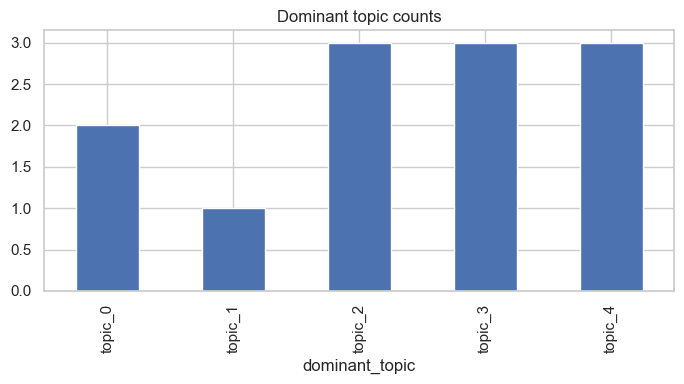

In [3]:
topic_counts = assign_dominant_topic(doc_topics, docs).dominant_topic.value_counts().sort_index()
topic_counts.plot(kind='bar', figsize=(7, 4), title='Dominant topic counts')
plt.tight_layout()